# Example: Forward modeling and window with RIC, auto-correlation

This notebook demonstrates how to compute a window matrix including geometry and RIC by forward modeling RIC on the autocorrelation of one tracer.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import lsstypes as lss
import matplotlib.pyplot as plt
from jaxpower import BinMesh2SpectrumPoles, FKPField, compute_fkp2_normalization, get_mesh_attrs
from tqdm import tqdm

from desiwinds.convenience import fiducial_planck_2018, get_randoms, split_into_fields
from desiwinds.forward import mock_survey_catalog, prepare_RIC
from desiwinds.window import get_window_spikes

## Parameters
Adjust data paths and redshift ranges to match your environment.

In [2]:
LOS = "local"
UNITARY_AMPLITUDE = True
nreal_fw = 15
nreal_wd = 3 # Low number of realizations for this example

n_randoms = 1

boxsize = 8000.0
cellsize = 40.0 # Lighter computations for this example

tracer = "LRG"
z_range = (0.4, 1.1)

pk_regions = ["SGC", "NGC"]
photo_regions = ["N", "S"]  # Photometric regions for LRG

data_to_randoms = 0.5 # Use half of the randoms catalogs as "data" and the other half and randoms

randoms_basedir = Path("/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/fNL")

## Load randoms and create catalogs

In [3]:
fkp_fields = []
fkp_norms = []

data = []
randoms = []

for pk_region in pk_regions:
    # Load data for single tracer
    position, [weight], redshift = get_randoms(
        n_randoms,
        pk_region,
        z_range,
        tracer,
        "default",
        basedir=randoms_basedir,
        return_redshift=True,
    )

    # Create mesh attributes
    mattrs = get_mesh_attrs(position, cellsize=cellsize, boxsize=boxsize, check=True)

    # Create data/randoms split
    _data, _randoms, _mask_is_data = split_into_fields(
        position,
        weight,
        extra_weights=None,
        data_size=int(weight.shape[0] * data_to_randoms),
        split_seed=123,
        mattrs=mattrs,
        exchange=True,
        backend="jax",
    )

    data.append(_data)
    randoms.append(_randoms)

    # Create FKP field
    fkp_field = FKPField(data=_data, randoms=_randoms, attrs=mattrs)
    fkp_fields.append(fkp_field)

    # Compute normalization
    binner = BinMesh2SpectrumPoles(mattrs=mattrs, edges={"step": 0.005}, ells=(0, 2, 4))
    fkp_norm = compute_fkp2_normalization(fkp_field, bin=binner, cellsize=10.0)
    fkp_norms.append(fkp_norm)

del position, weight, redshift


In [4]:
theory = fiducial_planck_2018(jnp.arange(0.0, jnp.pi / cellsize, 0.005))

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/code/cosmoprimo/main/lib/python3.12/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


## Build RIC arguments

In [5]:
ric_args = prepare_RIC(
    data=tuple(data),
    randoms=tuple(randoms),
    regions=photo_regions,
    n_bins=1000,
    apply_to="randoms",
)

jax.block_until_ready(ric_args)

RIC_args(data_distances_digitized=Array([244, 177, 177, ..., 237, 237, 237], dtype=int32), randoms_distances_digitized=Array([244, 177, 237, ..., 209, 237, 237], dtype=int32), data_regions=Array([[False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True]], dtype=bool), randoms_regions=Array([[False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True]], dtype=bool), data_to_remove=Array([False, False, False, ..., False, False, False], dtype=bool), n_bins=1000, apply_to='randoms')

## Forward modeling with and without RIC

In [6]:
fw_jit = jax.jit(mock_survey_catalog, static_argnames=["los", "unitary_amplitude"])
fw_nojit = mock_survey_catalog

In [7]:
pks_geo = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=None,
        amr_args=None,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        data_regions=ric_args.data_regions,
        randoms_regions=ric_args.randoms_regions,
    )
    for i in tqdm(range(nreal_fw), desc="Geometry forward modeling")
]

Geometry forward modeling: 100%|██████████| 15/15 [00:14<00:00,  1.02it/s]


Text(0.5, 1.0, 'Geometry-only power spectrum')

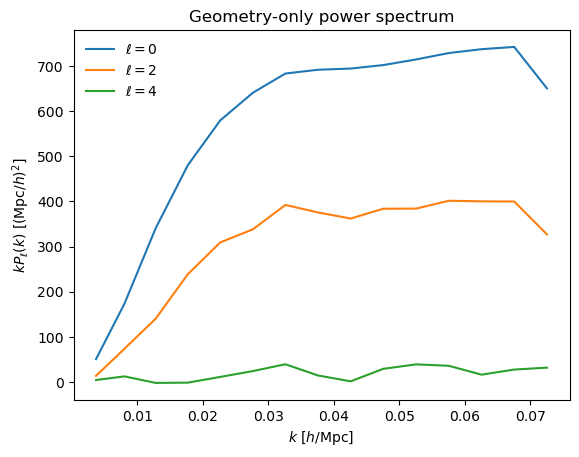

In [8]:
lss.mean(list(map(sum, pks_geo))).plot()
plt.title("Geometry-only power spectrum")

In [9]:
pks_ric = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=ric_args,
        amr_args=None,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        data_regions=ric_args.data_regions,
        randoms_regions=ric_args.randoms_regions,
    )
    for i in tqdm(range(nreal_fw), desc="RIC forward modeling")
]

RIC forward modeling: 100%|██████████| 15/15 [00:12<00:00,  1.17it/s]


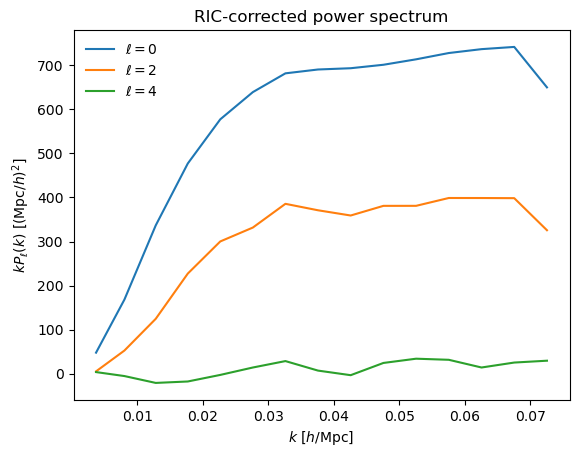

In [10]:
lss.mean(list(map(sum, pks_ric))).plot()
plt.title("RIC-corrected power spectrum");

Text(0.5, 0.98, 'RIC effect on power spectrum')

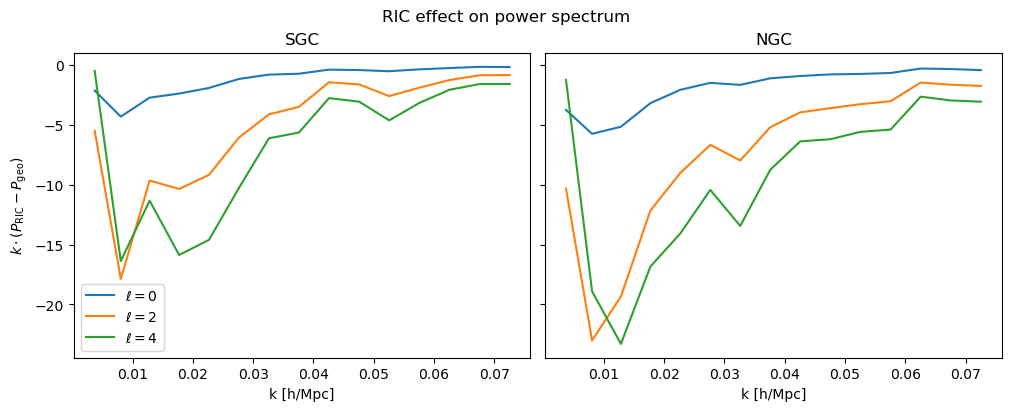

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, layout="constrained")

for isurvey, (ax, nsurvey) in enumerate(zip(axes, ["SGC", "NGC"])):
    for ell in [0, 2, 4]:
        pole_geo = lss.mean([pk_geo[isurvey] for pk_geo in pks_geo]).get(ell)
        pole_ric = lss.mean([pk_ric[isurvey] for pk_ric in pks_ric]).get(ell)
        k = pole_ric.coords("k")
        ax.plot(k, k * (pole_ric.value() - pole_geo.value()), label=f"$\\ell = ${ell}")
    ax.set_title(nsurvey)
    ax.set_xlabel("k [h/Mpc]")

axes[0].set_ylabel(r"$k \cdot (P_\mathrm{RIC} - P_\mathrm{geo})$")
axes[0].legend()
fig.suptitle("RIC effect on power spectrum")

# Window spikes with RIC

In [12]:
windows_avg, windows = get_window_spikes(
    mock_survey=mock_survey_catalog,
    theory=theory,
    nreal=nreal_wd,
    seeds=None,
    batch_size=10,
    mock_survey_args=(*fkp_fields,),
    mock_survey_kwargs={
        "los": LOS,
        "unitary_amplitude": UNITARY_AMPLITUDE,
        "ric_args": ric_args,
        "amr_args": None,
        "nam_args": None,
        "fkp_norms": fkp_norms,
        "binner": binner,
        "data_regions": ric_args.data_regions,
        "randoms_regions": ric_args.randoms_regions,
    },
    static_argnames=["los", "unitary_amplitude"],
)

Realization: 100%|██████████| 3/3 [00:41<00:00, 13.92s/it]


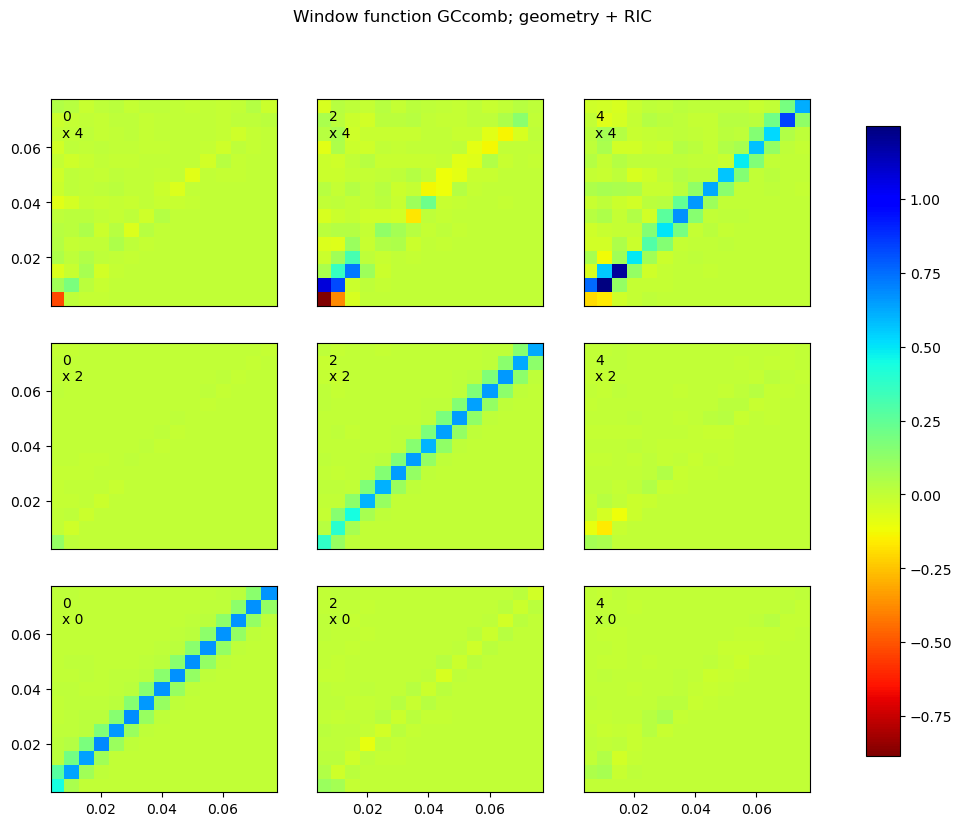

In [14]:
fig = sum(windows_avg).plot()
fig.suptitle("Window function GCcomb; geometry + RIC");